Weighted religion proportions within each cluster:
religious_affiliation  Christianity  Islam  Judaism  Buddhism  Hinduism  \
cluster                                                                   
0                             0.535  0.030    0.029     0.000     0.032   
1                             0.444  0.040    0.007     0.009     0.002   
2                             0.650  0.004    0.003     0.004     0.001   
3                             0.549  0.069    0.012     0.019     0.018   
4                             0.556  0.104    0.005     0.008     0.011   

religious_affiliation  No religious community  
cluster                                        
0                                       0.374  
1                                       0.498  
2                                       0.338  
3                                       0.333  
4                                       0.316  


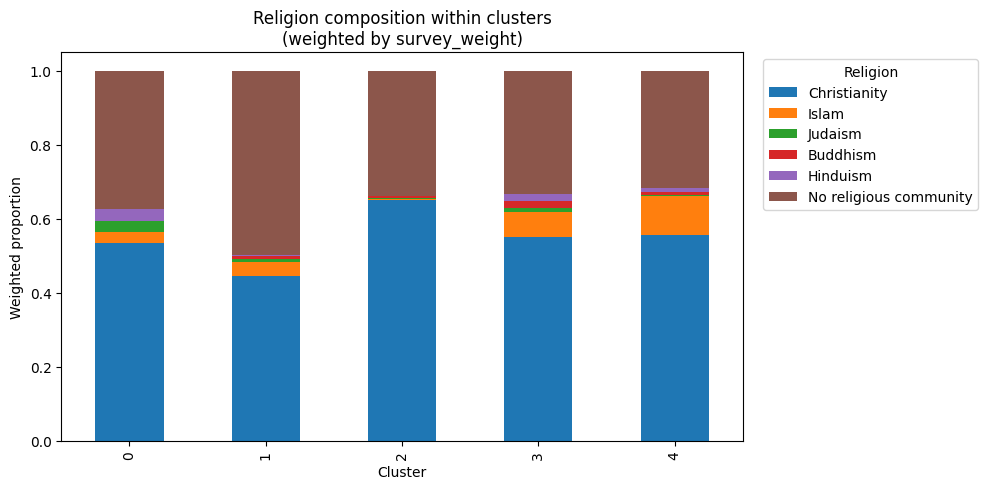

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans

# ---- Load ----
df = pd.read_csv("processed_dataset_ml.csv")  # adjust path if needed

RELIG_COL = "religious_affiliation"
WEIGHT_COL = "survey_weight"

# Only religion codes that exist in your data
valid_codes = [1, 2, 3, 4, 5, 7]
relig_map = {
    1: "Christianity",
    2: "Islam",
    3: "Judaism",
    4: "Buddhism",
    5: "Hinduism",
    7: "No religious community",
}

# ---- Filter valid religion responses ----
df = df[df[RELIG_COL].isin(valid_codes)].copy()

# ---- Clean survey weights ----
w = df[WEIGHT_COL].astype(float).to_numpy()
w = np.where(np.isfinite(w) & (w > 0), w, np.nan)
w = np.nan_to_num(w, nan=np.nanmedian(w[np.isfinite(w)]))

# ---- Select clustering features (numeric, excluding religion + weight) ----
numeric_cols = df.select_dtypes(include=[np.number]).columns
exclude = {RELIG_COL, WEIGHT_COL}
features = [c for c in numeric_cols if c not in exclude]

X = df[features].to_numpy()

# ---- Impute missing values ----
X_imp = SimpleImputer(strategy="median").fit_transform(X)

# ---- Weighted standardization ----
wsum = w.sum()
wmean = (X_imp * w[:, None]).sum(axis=0) / wsum
wvar = (w[:, None] * (X_imp - wmean) ** 2).sum(axis=0) / wsum
wstd = np.sqrt(np.maximum(wvar, 1e-12))
X_std = (X_imp - wmean) / wstd

# ---- PCA (speed + visualization) ----
X_red = PCA(n_components=min(15, X_std.shape[1]), random_state=42).fit_transform(X_std)

# ---- Weighted clustering ----
k = 5  # good default for presentation
km = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=4096,
    n_init=3,
    max_iter=60
)
km.fit(X_red, sample_weight=w)
df["cluster"] = km.labels_

# ---- Weighted religion composition per cluster ----
tmp = df[[RELIG_COL, "cluster"]].copy()
tmp["w"] = w

weighted_counts = (
    tmp.groupby(["cluster", RELIG_COL])["w"]
       .sum()
       .unstack(fill_value=0)
       .reindex(columns=valid_codes, fill_value=0)
)

weighted_props = weighted_counts.div(weighted_counts.sum(axis=1), axis=0)
weighted_props = weighted_props.rename(columns=relig_map)

print("Weighted religion proportions within each cluster:")
print(weighted_props.round(3))

# ---- Plot: stacked bar (presentation-ready) ----
ax = weighted_props.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Weighted proportion")
ax.set_title("Religion composition within clusters\n(weighted by survey_weight)")
ax.legend(title="Religion", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


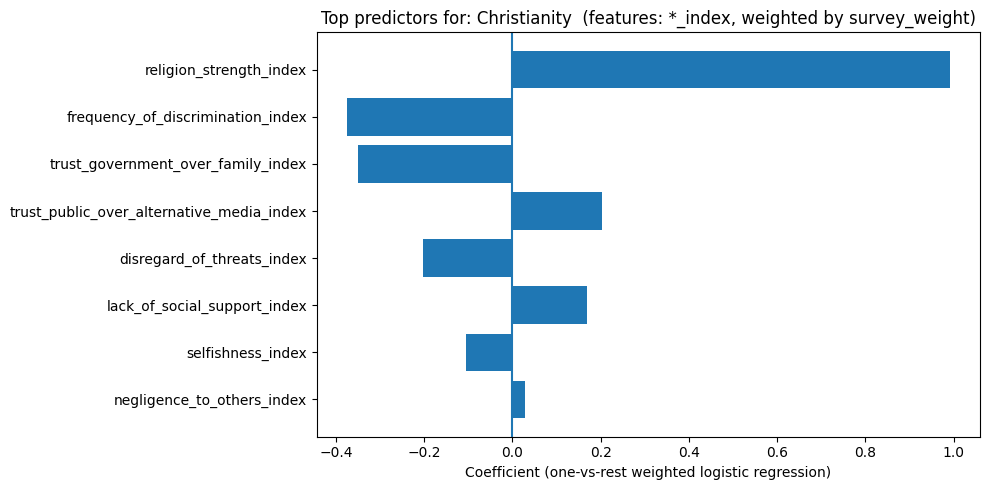

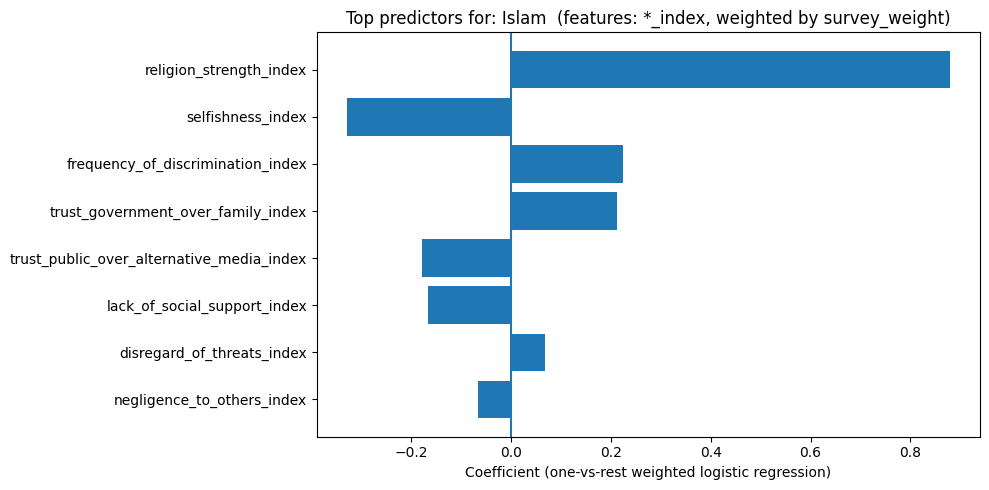

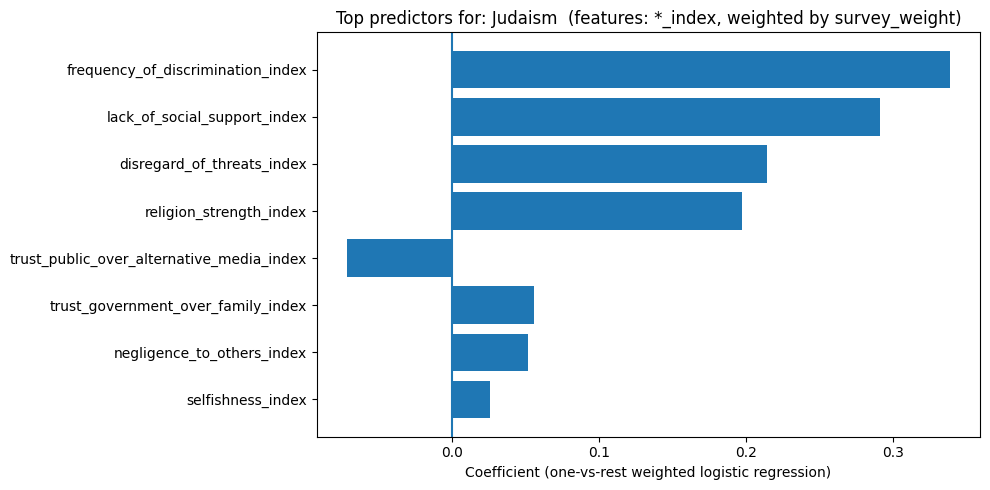

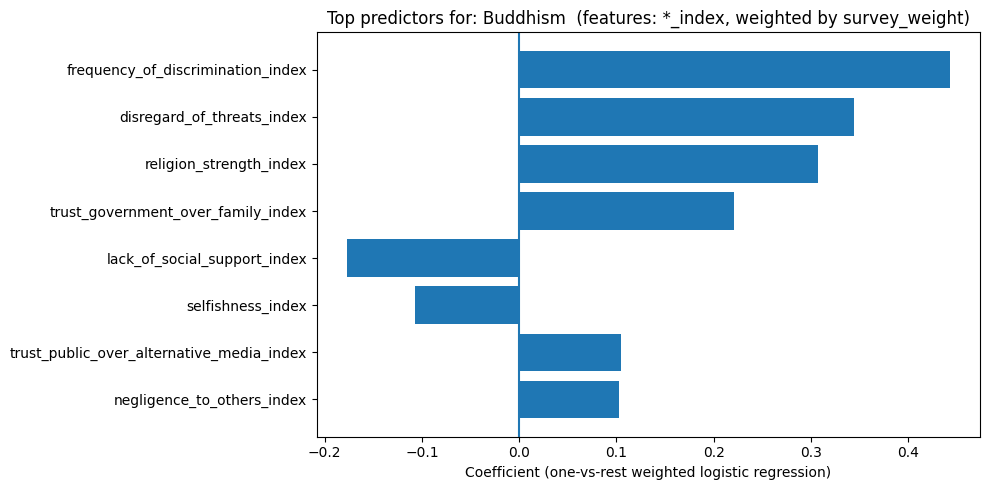

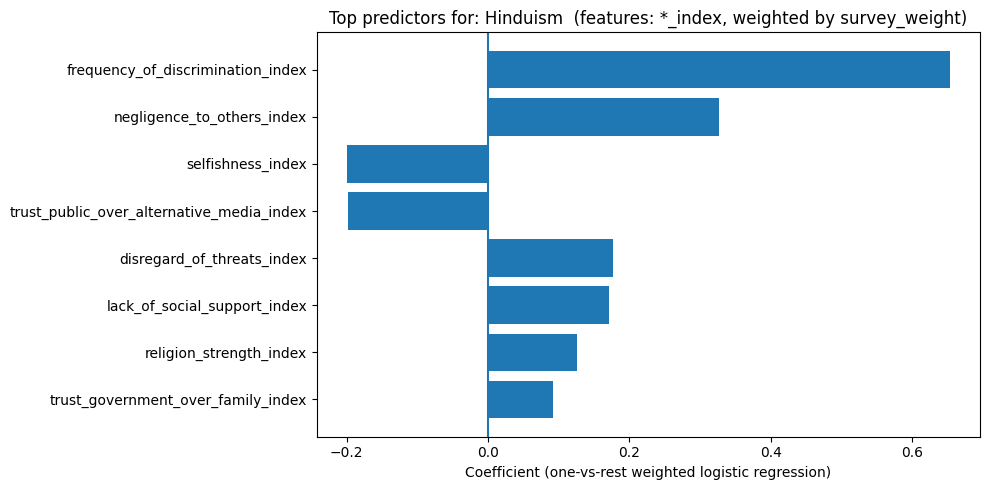

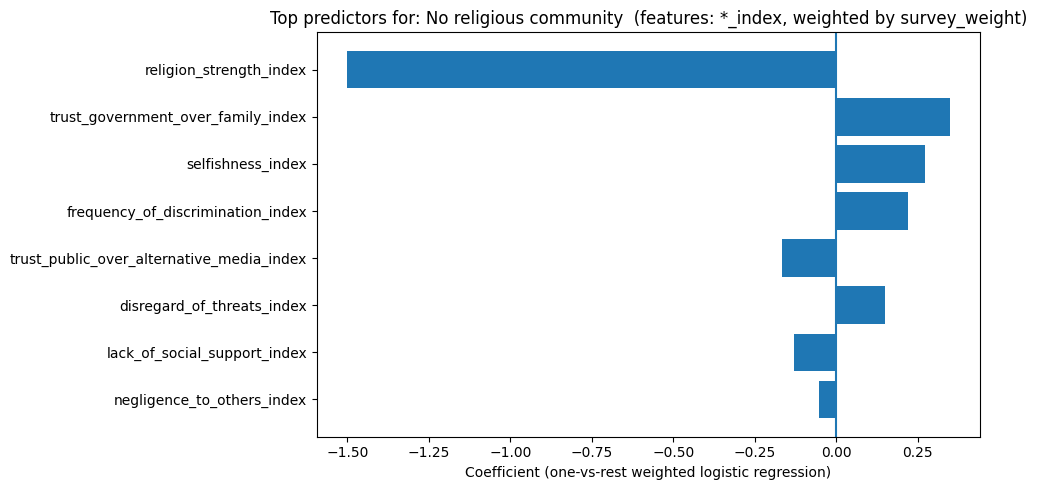

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---- Load ----
df = pd.read_csv("processed_dataset_ml.csv")  # adjust path if needed

TARGET = "religious_affiliation"
WEIGHT = "survey_weight"

valid_codes = [1, 2, 3, 4, 5, 7]
relig_map = {
    1: "Christianity",
    2: "Islam",
    3: "Judaism",
    4: "Buddhism",
    5: "Hinduism",
    7: "No religious community",
}

# ---- Filter valid target codes ----
df = df[df[TARGET].isin(valid_codes)].copy()

# ---- Extract weights ----
w = df[WEIGHT].astype(float).to_numpy()
w = np.where(np.isfinite(w) & (w > 0), w, np.nan)
w = np.nan_to_num(w, nan=np.nanmedian(w[np.isfinite(w)]))

# ---- Keep ONLY columns ending with _index (numeric only) ----
index_cols = [c for c in df.columns if c.endswith("_index")]
X = df[index_cols].copy()

# If any are non-numeric, coerce to numeric (invalid -> NaN)
for c in X.columns:
    X[c] = pd.to_numeric(X[c], errors="coerce")

y = df[TARGET].astype(int)

if X.shape[1] == 0:
    raise ValueError("No columns ending with '_index' were found.")

# ---- Train/test split (stratified) ----
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.25, random_state=42, stratify=y
)

# ---- Pipeline: impute -> scale -> weighted logistic regression ----
pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="liblinear", max_iter=2000))
])

TOP_N = 12  # number of features to show per religion

for code in valid_codes:
    # one-vs-rest target
    y_bin_train = (y_train == code).astype(int)

    # Fit with survey weights
    pipe.fit(X_train, y_bin_train, clf__sample_weight=w_train)

    # Coefficients: positive => increases probability of being in this religion group
    coef = pipe.named_steps["clf"].coef_.ravel()
    feats = np.array(index_cols)

    # pick top by absolute magnitude (strongest predictors)
    top_idx = np.argsort(np.abs(coef))[-TOP_N:][::-1]
    top_feats = feats[top_idx]
    top_coef = coef[top_idx]

    # ---- Plot (separate figure for each religion) ----
    plt.figure(figsize=(10, 5))
    plt.barh(top_feats[::-1], top_coef[::-1])
    plt.axvline(0)  # reference line
    plt.xlabel("Coefficient (one-vs-rest weighted logistic regression)")
    plt.title(f"Top predictors for: {relig_map[code]}  (features: *_index, weighted by survey_weight)")
    plt.tight_layout()
    plt.show()
